### Model construction/training steps
1. Features engineering
2. Cross-Validation
3. Model training
4. Features filtering based on mean importance over splits

### Imports

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit

### Read files & submission file for template

In [85]:
X_train = pd.read_csv('X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('sample_submission.csv',index_col='ROW_ID')

In [86]:
X_train.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP'],
      dtype='str')

### 1. Features Engineering (VERY IMPORTANT)
#### - Returns
1. Lag returns
2. Cross-sectional returns
3. Z-scored returns
4. Volume-normalized returns (unsigned vs. signed)
#### - Momentum features
1. Multi-horizon cumulative returns
2. Averaged cumulative returns over allocations within same time window
3. **Exponentially weighted momentum (EW momentum)**
4. Averaged EW momentum over allocations within same time window
5. Dispersion of EW momentum over allocations within same time window
6. Z-score (cross-sectional normalization) for relative standing
#### - Volume features
1. Mean signed volume
2. Cross-sectional mean signed volume
3. Absolute volume
4. Price-volume alignment
#### - Volatility features
1. Volatility for the last 20 days
2. Cross-sectional volatility
#### - Observation from features importance plot
1. **The two most dominant features: returns on the last 1st and 4th days**
    - Better making this information significant by introducing contrast, sum, sign agreement and asymmetry
2. Highly correlated features may not simultaneously significant in importance ranking
    - Ex. EW momentum and momentum for same horizons

In [87]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [88]:
for i in range(1,21):
    X_train[f'ALLOCATIONS_AVERAGE_RET_{i}'] = X_train.groupby('TS')[ f'RET_{i}'].transform('mean')
    X_train[f'ALLOCATIONS_STD_RET_{i}'] = X_train.groupby('TS')[ f'RET_{i}'].transform('std')
    X_train[f'ALLOCATIONS_RET_Z_{i}'] = (X_train[ f'RET_{i}'] - X_train[ f'ALLOCATIONS_AVERAGE_RET_{i}']) / X_train[ f'ALLOCATIONS_STD_RET_{i}']
    X_train[f'RET_VOL_NORM_{i}'] = X_train[f'RET_{i}']/ (np.abs(X_train[f'SIGNED_VOLUME_{i}']) + 1e-6)

    X_test[f'ALLOCATIONS_AVERAGE_RET_{i}'] = X_test.groupby('TS')[ f'RET_{i}'].transform('mean')
    X_test[f'ALLOCATIONS_STD_RET_{i}'] = X_test.groupby('TS')[ f'RET_{i}'].transform('std')
    X_test[f'ALLOCATIONS_RET_Z_{i}'] = (X_test[ f'RET_{i}'] - X_test[ f'ALLOCATIONS_AVERAGE_RET_{i}']) / X_test[ f'ALLOCATIONS_STD_RET_{i}']
    X_test[f'RET_VOL_NORM_{i}'] = X_test[f'RET_{i}']/ (np.abs(X_test[f'SIGNED_VOLUME_{i}']) + 1e-6)

for i in [3,5,10,15,20]:
    # Classical momentum and group-level average momentum
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

    # Exponentially weighted momentum and group-level average and std of the exponentially weighted momentum
    hl = i / 2
    alpha = np.log(2)/hl
    ewm_weights = np.exp(-alpha*np.arange(i))
    ewm_weights /= ewm_weights.sum()
    X_train[ f'EWM_MOMENTUM_{i}'] = X_train[RET_features[:i]].fillna(0).dot(ewm_weights)
    X_train[ f'ALLOCATIONS_EWM_MOMENTUM_{i}'] = X_train.groupby('TS')[ f'EWM_MOMENTUM_{i}'].transform('mean')
    X_train[ f'ALLOCATIONS_EWM_MOMENTUM_STD_{i}'] = X_train.groupby('TS')[ f'EWM_MOMENTUM_{i}'].transform('std')
    X_train[ f'ALLOCATIONS_EWM_MOMENTUM_Z_{i}'] = (X_train[ f'EWM_MOMENTUM_{i}'] - X_train[ f'ALLOCATIONS_EWM_MOMENTUM_{i}']) / X_train[ f'ALLOCATIONS_EWM_MOMENTUM_STD_{i}']
    
    X_test[ f'EWM_MOMENTUM_{i}'] = X_test[RET_features[:i]].fillna(0).dot(ewm_weights)
    X_test[ f'ALLOCATIONS_EWM_MOMENTUM_{i}'] = X_test.groupby('TS')[ f'EWM_MOMENTUM_{i}'].transform('mean')
    X_test[ f'ALLOCATIONS_EWM_MOMENTUM_STD_{i}'] = X_test.groupby('TS')[ f'EWM_MOMENTUM_{i}'].transform('std')
    X_test[ f'ALLOCATIONS_EWM_MOMENTUM_Z_{i}'] = (X_test[ f'EWM_MOMENTUM_{i}'] - X_test[ f'ALLOCATIONS_EWM_MOMENTUM_{i}']) / X_test[ f'ALLOCATIONS_EWM_MOMENTUM_STD_{i}']

    # Order flow features
    X_train[ f'AVERAGE_SIGNED_VOLUME_{i}'] = X_train[SIGNED_VOLUME_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_SIGNED_VOLUME_{i}'] = X_train.groupby('TS')[ f'AVERAGE_SIGNED_VOLUME_{i}'].transform('mean')
    X_train[ f'AVERAGE_ABS_SIGNED_VOLUME_{i}'] = np.abs(X_train[SIGNED_VOLUME_features[:i]]).mean(1)

    X_test[ f'AVERAGE_SIGNED_VOLUME_{i}'] = X_test[SIGNED_VOLUME_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_SIGNED_VOLUME_{i}'] = X_test.groupby('TS')[ f'AVERAGE_SIGNED_VOLUME_{i}'].transform('mean')
    X_test[ f'AVERAGE_ABS_SIGNED_VOLUME_{i}'] = np.abs(X_test[SIGNED_VOLUME_features[:i]]).mean(1)

    # Price-volume alignment features
    X_train[ f'PRICE_VOLUME_ALIGNMENT_{i}'] = (X_train[RET_features[:i]] * X_train[SIGNED_VOLUME_features[:i]]).mean(1)
    X_train[ f'ALLOCATIONS_PRICE_VOLUME_ALIGNMENT_{i}'] = X_train.groupby('TS')[ f'PRICE_VOLUME_ALIGNMENT_{i}'].transform('mean')

    X_test[ f'PRICE_VOLUME_ALIGNMENT_{i}'] = (X_test[RET_features[:i]] * X_test[SIGNED_VOLUME_features[:i]]).mean(1)
    X_test[ f'ALLOCATIONS_PRICE_VOLUME_ALIGNMENT_{i}'] = X_test.groupby('TS')[ f'PRICE_VOLUME_ALIGNMENT_{i}'].transform('mean')

# Engineering features using return on the last 1st day and the last 4th day
X_train['RET_1_4_RATIO'] = X_train['RET_1'] / (X_train['RET_4'] + 1e-6)
X_train['RET_1_4_DIFF'] = X_train['RET_1'] - X_train['RET_4']
X_train['RET_1_4_PRODUCT'] = X_train['RET_1'] * X_train['RET_4']
X_train['RET_1_4_ASYMMETRY'] = X_train['RET_1'] / (X_train['RET_4'] + 1e-6) - X_train['RET_4'] / (X_train['RET_1'] + 1e-6)
X_train['ALLOCATIONS_RET_1'] = X_train.groupby('TS')['RET_1'].transform('mean')
X_train['ALLOCATIONS_RET_4'] = X_train.groupby('TS')['RET_4'].transform('mean')
X_train['ALLOCATIONS_RET_1_4_RATIO'] = X_train.groupby('TS')['RET_1_4_RATIO'].transform('mean')
X_train['ALLOCATIONS_RET_1_4_DIFF'] = X_train.groupby('TS')['RET_1_4_DIFF'].transform('mean')
X_train['ALLOCATIONS_RET_1_4_PRODUCT'] = X_train.groupby('TS')['RET_1_4_PRODUCT'].transform('mean')
X_train['ALLOCATIONS_RET_1_4_ASYMMETRY'] = X_train.groupby('TS')['RET_1_4_ASYMMETRY'].transform('mean')

X_test['RET_1_4_RATIO'] = X_test['RET_1'] / (X_test['RET_4'] + 1e-6)
X_test['RET_1_4_DIFF'] = X_test['RET_1'] - X_test['RET_4']
X_test['RET_1_4_PRODUCT'] = X_test['RET_1'] * X_test['RET_4']
X_test['RET_1_4_ASYMMETRY'] = X_test['RET_1'] / (X_test['RET_4'] + 1e-6) - X_test['RET_4'] / (X_test['RET_1'] + 1e-6)
X_test['ALLOCATIONS_RET_1'] = X_test.groupby('TS')['RET_1'].transform('mean')
X_test['ALLOCATIONS_RET_4'] = X_test.groupby('TS')['RET_4'].transform('mean')
X_test['ALLOCATIONS_RET_1_4_RATIO'] = X_test.groupby('TS')['RET_1_4_RATIO'].transform('mean')
X_test['ALLOCATIONS_RET_1_4_DIFF'] = X_test.groupby('TS')['RET_1_4_DIFF'].transform('mean')
X_test['ALLOCATIONS_RET_1_4_PRODUCT'] = X_test.groupby('TS')['RET_1_4_PRODUCT'].transform('mean')
X_test['ALLOCATIONS_RET_1_4_ASYMMETRY'] = X_test.groupby('TS')['RET_1_4_ASYMMETRY'].transform('mean')



for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')


/var/folders/gn/gk3b5h5x1cg32l5j8n1ggc6h0000gn/T/ipykernel_52074/358232184.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f'ALLOCATIONS_RET_Z_{i}'] = (X_train[ f'RET_{i}'] - X_train[ f'ALLOCATIONS_AVERAGE_RET_{i}']) / X_train[ f'ALLOCATIONS_STD_RET_{i}']
/var/folders/gn/gk3b5h5x1cg32l5j8n1ggc6h0000gn/T/ipykernel_52074/358232184.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f'RET_VOL_NORM_{i}'] = X_train[f'RET_{i}']/ (np.abs(X_train[f'SIGNED_VOLUME_{i}']) + 1e-6)
/var/folders/gn/gk3b5h5x1cg32l5j8n1ggc6h

In [89]:
# features = SIGNED_VOLUME_features + TURNOVER_features
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
# features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
# features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'EWM_MOMENTUM_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_EWM_MOMENTUM_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_EWM_MOMENTUM_STD_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_EWM_MOMENTUM_Z_{i}' for i in [3,5,10,15,20]]
features = features + [ f'AVERAGE_SIGNED_VOLUME_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_SIGNED_VOLUME_{i}' for i in [3,5,10,15,20]]
features = features + [ f'AVERAGE_ABS_SIGNED_VOLUME_{i}' for i in [3,5,10,15,20]]
features = features + [ f'PRICE_VOLUME_ALIGNMENT_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_PRICE_VOLUME_ALIGNMENT_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]
features = features + ['RET_1_4_RATIO', 'RET_1_4_DIFF', 'RET_1_4_PRODUCT', 'RET_1_4_ASYMMETRY', 'ALLOCATIONS_RET_1', 'ALLOCATIONS_RET_4', 'ALLOCATIONS_RET_1_4_RATIO', 'ALLOCATIONS_RET_1_4_DIFF', 'ALLOCATIONS_RET_1_4_PRODUCT', 'ALLOCATIONS_RET_1_4_ASYMMETRY']
features = features + [ f'ALLOCATIONS_RET_Z_{i}' for i in range(1,21)]
features = features + [ f'ALLOCATIONS_AVERAGE_RET_{i}' for i in range(1,21)]
features = features + [ f'ALLOCATIONS_STD_RET_{i}' for i in range(1,21)]
features = features + [ f'RET_VOL_NORM_{i}' for i in range(1,21)]



### Fitting one simple Ridge (linear regression model)

In [90]:
new_ridge = linear_model.Ridge(alpha=1)

new_ridge.fit(X_train[features].to_numpy(na_value=0),y_train.to_numpy(na_value=0))

preds_ridge = pd.DataFrame(new_ridge.predict(X_test[features].fillna(0).to_numpy(na_value=0)), index = sample_submission.index,columns=['target'])

In [91]:
(preds_ridge>0).astype(int).to_csv('preds_ridge_bench.csv')

### 2. & 3. Cross Validation and Model Training
#### - Model selection
1. Lightbgm
2. XGBoost
#### - Cross-Validation
1. Standard shuffled k-fold
2. Time-Series Cross-Validation

In [92]:
features_lgbm = features

In [93]:

# A quite large number of trees with low depth to prevent overfits
lgbm_params = {
                "objective": "mse",
                "metric": "mse",
                "num_threads": 50,
                "seed": 42,
                "verbosity": -1,
                'learning_rate': 1e-2,
                'max_depth': 3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8
scores_lgbm = []
models_lgbm = []
 
# splits = KFold(n_splits=n_splits, random_state=0, shuffle=True,).split(train_dates) # KFold split to compare with the time-series split
splits = TimeSeriesSplit(n_splits=n_splits).split(train_dates); # Time-Series split to prevent look-ahead bias

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
    y_local_train = y_train.loc[local_train_ids,'target']
    
    X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
    y_local_test = y_train.loc[local_test_ids,'target']
    
    X_local_train = X_local_train
    X_local_test = X_local_test

    train_data = lgbm.Dataset(X_local_train, label=y_local_train.values) 
    
    model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
    
    y_local_pred = model_lgbm.predict(X_local_test.values, num_threads = lgbm_params['num_threads'])
    
    
    models_lgbm.append(model_lgbm)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_lgbm.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_lgbm)*100
std = np.std(scores_lgbm)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


Fold 1 - Accuracy: 50.87%
Fold 2 - Accuracy: 52.16%
Fold 3 - Accuracy: 50.67%
Fold 4 - Accuracy: 51.33%
Fold 5 - Accuracy: 51.74%
Fold 6 - Accuracy: 52.47%
Fold 7 - Accuracy: 52.48%
Fold 8 - Accuracy: 52.11%
Accuracy: 51.73% [51.07 ; 52.38] (+- 0.66)


### 4. Features filtering based on mean importance over splits
1. Gain importance - predictive power
2. Split importance - stablility

/var/folders/gn/gk3b5h5x1cg32l5j8n1ggc6h0000gn/T/ipykernel_52074/2595223805.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]


<Axes: title={'center': 'Feature Importances - Gain'}>

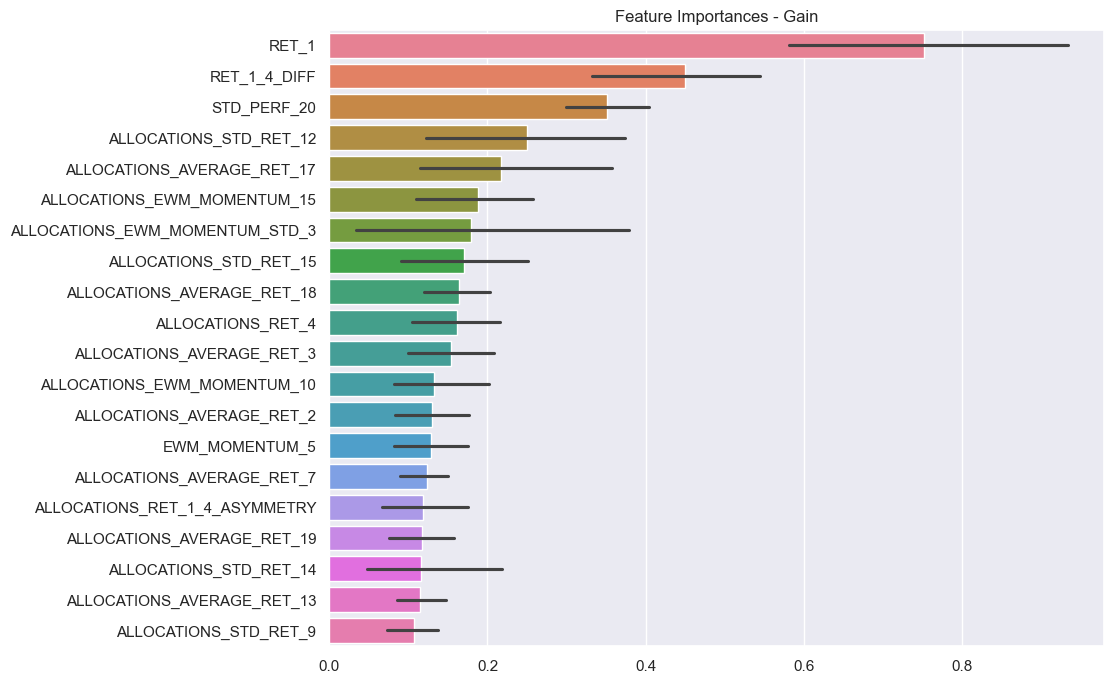

In [94]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))
plt.title('Feature Importances - Gain')

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)


/var/folders/gn/gk3b5h5x1cg32l5j8n1ggc6h0000gn/T/ipykernel_52074/2755743708.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]


<Axes: title={'center': 'Feature Importances - Split'}>

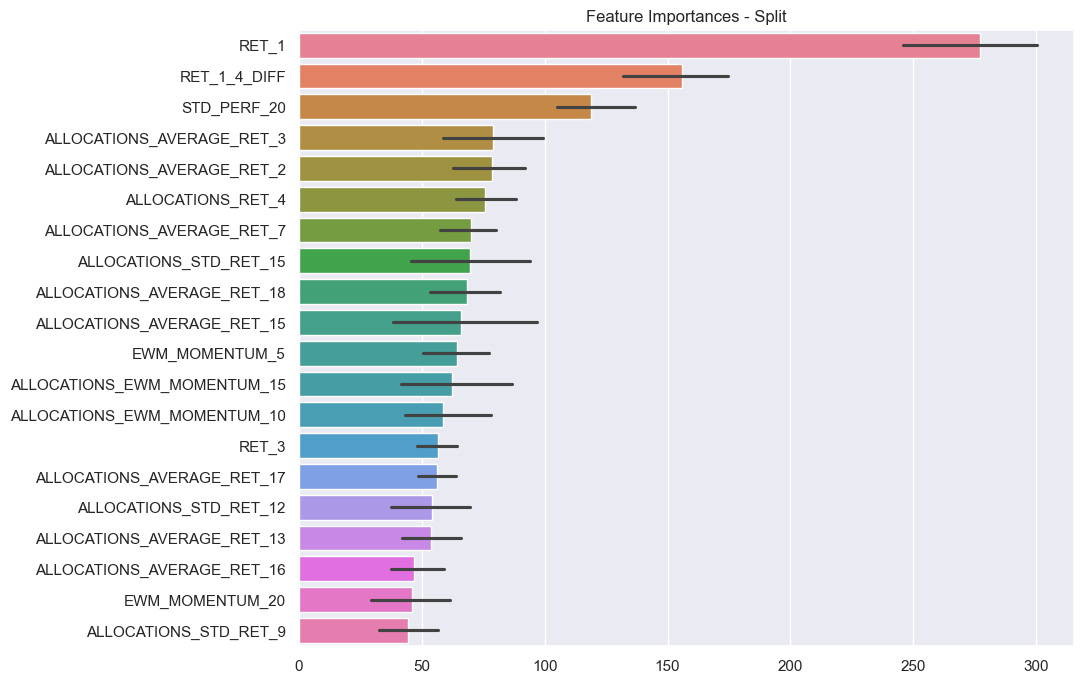

In [95]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='split') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))
plt.title('Feature Importances - Split')

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)

In [96]:
train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train) 

model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index,columns=['target']) 


In [97]:
(preds_lgbm>0).astype(int).to_csv('preds_lgbm_bench.csv')